# GDEX-GMF `pr`: before and after the chronic-zero fill

`gdex-gmf` is the observational target for the regional (South Africa) BCSD runs, and those runs
come out with blocky artifacts in `pr`. The store was modified after it was first materialized:
[the chronic-zero patch](https://github.com/carbonplan/srm-downscaling/issues/517) replaced exact
zeros with a small constant on day-of-year windows that never see rain in any training year, so the
parametric tail fits in the debiaser have something to work with.

This notebook asks whether that patch is the source of the blocks. Both versions of the store are
still reachable, because icechunk keeps the pre-patch snapshot in the `main` ancestry:

| Version | Snapshot | What it is |
|---|---|---|
| post-fix | `main` tip | What every recent run has read |
| pre-fix | last commit before the patch | The store as originally materialized from GDEX |

Three things get compared over South Africa: the all-time mean of each version, their difference,
and where the fill actually landed. The patch writes `FILL_CONST = 1e-6` kg m-2 s-1 (0.0864 mm/day)
in place of zeros, so a cell whose every day was filled shifts by at most 0.0864 mm/day. Whether
that is enough to matter depends on how many days per cell were touched, which is what section 4
measures.

Section 6 coarsens the difference to the debias grid. The artifacts in the obs-comparison figures
sit on blocks much larger than this store's 0.25 degree cells, so a fill that is invisible at
native resolution can still move a coarse cell enough to change its quantile mapping.

In [2]:
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import coiled
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask_array.xarray import register

from saidownscale.config import ClusterConfig
from saidownscale.datasets import catalog

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
VARIABLE = "pr"

# South Africa, matching the extent of the obs-comparison figures where the blocks appear.
LAT_SLICE = slice(-35.5, -21.5)
LON_SLICE = slice(15.0, 34.0)

# The patch rewrote the whole record, not only the training window, so compare the whole record.
TIME_SLICE = slice("1950-01-01", "2008-12-31")

# Commit message the patch writes (srm.input_data.gdex_gmf.patch_dry_pixels).
FIX_MESSAGE = "fixed empty rolling windows without rain"

# The constant the patch substitutes for zero, and the BCSD training window it scanned.
FILL_CONST = 1e-6
TRAIN_PERIOD = ("1960", "2008")

# Cells per coarse block in section 6. The store is 0.25 degree, so 4 gives 1 degree.
COARSEN_FACTOR = 4

SECONDS_PER_DAY = 86400  # kg m-2 s-1 -> mm/day

## 1. Resolving the two snapshots

Snapshots are found by walking the `main` ancestry rather than pinned by id, so the notebook keeps
working if the patch is re-run. The patch ran twice (the first attempt was superseded), so the
pre-fix snapshot is the first ancestor whose message is *not* the patch message.

This cell reads repository metadata only; it is cheap enough to run from a laptop.

In [3]:
entry = catalog.get("GDEX-GMF")
repo = icechunk.Repository.open(
    icechunk.s3_storage(bucket=entry.bucket, prefix=entry.prefix, from_env=True)
)

ancestry = list(repo.ancestry(branch="main"))
post_snap = ancestry[0]
pre_snap = next(c for c in ancestry if c.message != FIX_MESSAGE)

if post_snap.message != FIX_MESSAGE:
    raise ValueError(f"main tip is not a patch commit: {post_snap.message!r}")

pd.DataFrame(
    [
        {
            "version": "post-fix",
            "snapshot": post_snap.id,
            "written_at": post_snap.written_at,
            "message": post_snap.message,
        },
        {
            "version": "pre-fix",
            "snapshot": pre_snap.id,
            "written_at": pre_snap.written_at,
            "message": pre_snap.message,
        },
    ]
)

,version,snapshot,written_at,message
0,post-fix,JDXW379J5VS6FY64MSPG,2026-08-04 20:07:21.276775+00:00,fixed empty rolling windows without rain
1,pre-fix,NWTCZBZAT55KG27YRSY0,2026-07-30 01:33:49.554314+00:00,GDEX: rsds


In [4]:
def open_snapshot(snapshot_id: str) -> xr.Dataset:
    """Open the GDEX-GMF store as it stood at ``snapshot_id``."""
    session = repo.readonly_session(snapshot_id=snapshot_id)
    return xr.open_dataset(
        session.store, engine="zarr", chunks="auto", consolidated=False, zarr_format=3
    )


def region(ds: xr.Dataset) -> xr.DataArray:
    """Subset to the variable, period, and box under test."""
    return ds[VARIABLE].sel(time=TIME_SLICE, lat=LAT_SLICE, lon=LON_SLICE)


pre = region(open_snapshot(pre_snap.id))
post = region(open_snapshot(post_snap.id))

# Same grid and calendar in both, or the differences below would be comparing unlike cells.
xr.testing.assert_identical(pre["time"], post["time"])
xr.testing.assert_identical(pre["lat"], post["lat"])
xr.testing.assert_identical(pre["lon"], post["lon"])

full_gb = np.prod(list(open_snapshot(post_snap.id)[VARIABLE].shape)) * 4 / 1e9
print(f"region: {dict(post.sizes)}")
print(f"read: about {2 * full_gb:.0f} GB, both snapshots")

region: {'time': 21550, 'lat': 56, 'lon': 76}
read: about 179 GB, both snapshots


## 2. Compute

The region is small but the read is not. Chunks in this store are one global timestep
(`time=1, lat=720, lon=1440`), so subsetting to South Africa saves nothing on the read: every day
of both snapshots comes through the cluster, about 180 GB in total. Run it in `us-west-2`.

Everything stays lazy until a single `compute`, so the two snapshots and all five reductions fuse
into one pass over each array.

In [5]:
cfg = ClusterConfig(
    n_workers=10,
    worker_vm_types=["r8g.2xlarge"],
    scheduler_vm_types=["c8g.large"],
)
cluster = coiled.Cluster(
    name="srm-qa-gdex-pr-before-after",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
)
client = hijack(cluster.get_client())
client

[2026-08-06 15:03:55,595][INFO    ][coiled] Fetching latest package priorities...
[2026-08-06 15:03:55,597][INFO    ][coiled.package_sync] Resolving your local /Users/nrhagen/Documents/carbonplan/SRM/uv.lock Python environment...
[2026-08-06 15:03:55,788][INFO    ][coiled.package_sync] Scanning 290 python packages...
[2026-08-06 15:03:56,089][INFO    ][coiled] Running pip check...
[2026-08-06 15:03:56,421][INFO    ][coiled] Validating environment...
[2026-08-06 15:03:57,152][INFO    ][coiled] Creating wheel for ~/Documents/carbonplan/SRM/src...
[2026-08-06 15:03:57,269][INFO    ][coiled] Creating wheel for srm...
[2026-08-06 15:03:59,643][INFO    ][coiled] Uploading coiled_local_src...
[2026-08-06 15:04:01,010][INFO    ][coiled] Uploading srm...
[2026-08-06 15:04:02,526][INFO    ][coiled] Creating software environment...
[2026-08-06 15:04:03,862][INFO    ][coiled] Creating Cluster (name: srm-qa-gdex-pr-before-after, https://cloud.coiled.io/clusters/1893158 ). This usually takes 1-2 min

<frisky.Client: scheduler="wss://cluster-ojzoq.dask.host/xVSzgiJQd30SF23c/frisky-comm?__frisky_dial_host=18.246.216.82" id="client-0">

In [6]:
# NaN != NaN is True, so the ocean would count as changed without the notnull guards.
changed = (post != pre) & pre.notnull() & post.notnull()

stats = xr.Dataset(
    {
        "pre_mean": pre.mean("time"),
        "post_mean": post.mean("time"),
        "diff_mean": (post - pre).mean("time"),
        "filled_days": changed.sum("time"),
        "pre_zero_days": ((pre == 0) & pre.notnull()).sum("time"),
    }
)
stats["n_days"] = post.sizes["time"]

result = stats.compute()
result

<xarray.Dataset> Size: 120kB
Dimensions:        (lat: 56, lon: 76)
Coordinates:
  * lat            (lat) float64 448B -35.38 -35.12 -34.88 ... -21.88 -21.62
  * lon            (lon) float64 608B 15.12 15.38 15.62 ... 33.38 33.62 33.88
Data variables:
    pre_mean       (lat, lon) float32 17kB 1.404e-05 1.404e-05 ... 2.562e-05
    post_mean      (lat, lon) float32 17kB 1.404e-05 1.404e-05 ... 2.562e-05
    diff_mean      (lat, lon) float32 17kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    filled_days    (lat, lon) int64 34kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    pre_zero_days  (lat, lon) int64 34kB 16203 16203 16203 ... 18326 18323 18323
    n_days         int64 8B 21550

In [7]:
# Work in mm/day from here on; kg m-2 s-1 puts every number at 1e-6 and hides the comparison.
mm = result[["pre_mean", "post_mean", "diff_mean"]] * SECONDS_PER_DAY
mm["filled_fraction"] = result.filled_days / result.n_days
mm["pre_zero_fraction"] = result.pre_zero_days / result.n_days
mm["diff_pct"] = 100 * result.diff_mean / result.pre_mean

land = result.pre_mean.notnull()
touched = result.filled_days > 0

summary = pd.Series(
    {
        "land cells in box": int(land.sum()),
        "cells with any fill": int((touched & land).sum()),
        "fraction of cells filled": float((touched & land).sum() / land.sum()),
        "max filled days (of n_days)": int(result.filled_days.max()),
        "max filled fraction": float(mm.filled_fraction.max()),
        "mean pr [mm/day]": float(mm.pre_mean.mean()),
        "max |diff| [mm/day]": float(abs(mm.diff_mean).max()),
        "max |diff| [% of pre-fix mean]": float(abs(mm.diff_pct).max()),
        "upper bound on diff [mm/day]": FILL_CONST * SECONDS_PER_DAY,
    }
)
summary

land cells in box                  4256.000000
cells with any fill                 941.000000
fraction of cells filled              0.221100
max filled days (of n_days)       12405.000000
max filled fraction                   0.575638
mean pr [mm/day]                      1.129749
max |diff| [mm/day]                   0.049735
max |diff| [% of pre-fix mean]      208.218185
upper bound on diff [mm/day]          0.086400
dtype: float64

## 3. All-time mean, before and after

The first two panels share a color scale, so any visible change between them is a real one. The
third is the difference at native 0.25 degree resolution. The fill can only ever add precipitation,
so the difference is non-negative everywhere by construction; a negative value would mean the patch
wrote something other than what it claims.

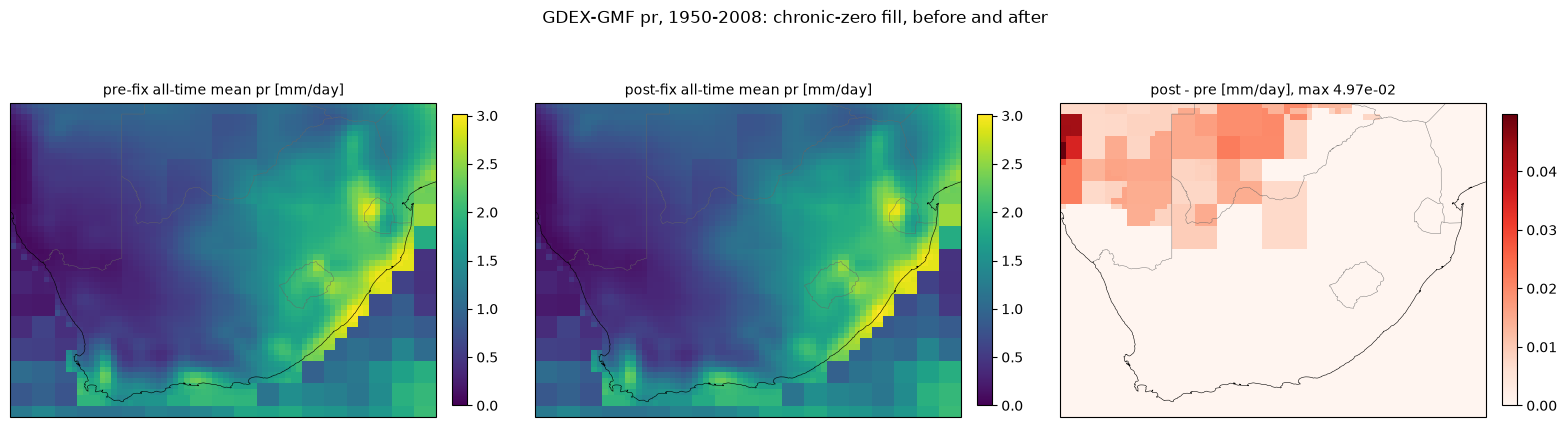

In [8]:
def draw(ax, da, title, **kw):
    im = da.plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, **kw)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.4")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.75, pad=0.03)
    return im


vmax = float(max(mm.pre_mean.max(), mm.post_mean.max()))
dmax = float(abs(mm.diff_mean).max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), subplot_kw={"projection": ccrs.PlateCarree()})
draw(axes[0], mm.pre_mean, "pre-fix all-time mean pr [mm/day]", cmap="viridis", vmin=0, vmax=vmax)
draw(axes[1], mm.post_mean, "post-fix all-time mean pr [mm/day]", cmap="viridis", vmin=0, vmax=vmax)
draw(
    axes[2],
    mm.diff_mean,
    f"post - pre [mm/day], max {dmax:.2e}",
    cmap="Reds",
    vmin=0,
    vmax=max(dmax, 1e-12),
)
fig.suptitle(
    f"GDEX-GMF pr, {TIME_SLICE.start[:4]}-{TIME_SLICE.stop[:4]}: chronic-zero fill, before and after",
    y=1.02,
)
fig.tight_layout()

## 4. Where the fill landed

The difference map above is bounded by `FILL_CONST` and says little on its own. What matters for
the blocks is the *pattern*: a fill scattered over isolated cells cannot make a block, while a fill
concentrated on contiguous patches can.

`filled_fraction`
: Days per cell the patch rewrote, as a fraction of the record. This is the fingerprint to compare
  against the artifact.

`pre_zero_fraction`
: Days that were exactly zero before the patch. Its difference from `filled_fraction` is the zeros
  the scan left alone, which are the ones that fall outside an always-dry day-of-year window.

`diff_pct`
: The difference as a percentage of the pre-fix mean. A cell that is dry to begin with can be moved
  a large fraction by a small absolute fill, and it is the relative shift the quantile mapping sees.

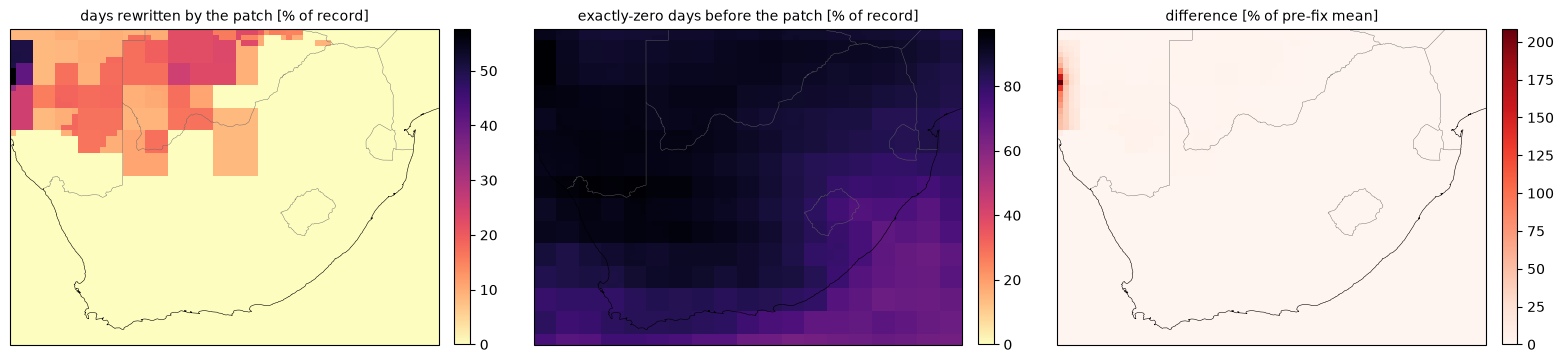

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), subplot_kw={"projection": ccrs.PlateCarree()})
draw(
    axes[0],
    100 * mm.filled_fraction,
    "days rewritten by the patch [% of record]",
    cmap="magma_r",
    vmin=0,
)
draw(
    axes[1],
    100 * mm.pre_zero_fraction,
    "exactly-zero days before the patch [% of record]",
    cmap="magma_r",
    vmin=0,
)
draw(
    axes[2],
    mm.diff_pct,
    "difference [% of pre-fix mean]",
    cmap="Reds",
    vmin=0,
)
fig.tight_layout()

## 5. Distribution of the shift

Two histograms over land cells: how much each cell moved in absolute terms, and how much it moved
relative to its own mean. The relative one is the one to read against the artifact, whose amplitude
in the obs-comparison figures runs to a few percent of the local mean.

cells moved > 0.001 mm/day    941.000000
cells moved > 1%              724.000000
cells moved > 5%               65.000000
99th pct shift [% of mean]     18.296782
dtype: float64

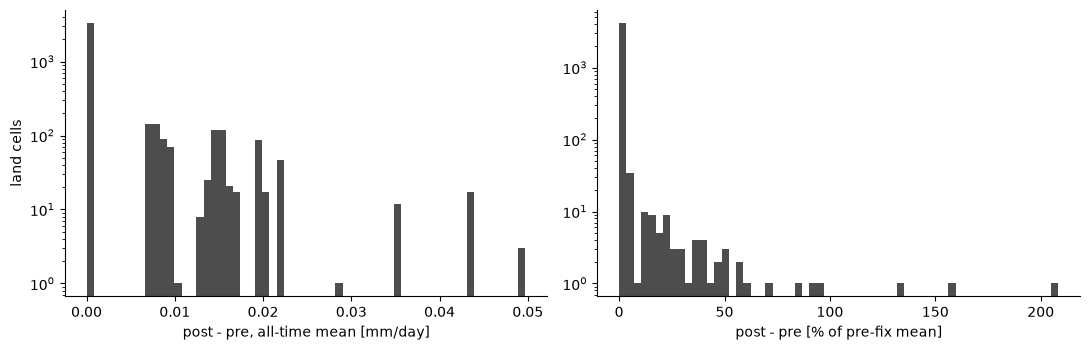

In [10]:
diff_land = mm.diff_mean.where(land).values.ravel()
pct_land = mm.diff_pct.where(land).values.ravel()
diff_land = diff_land[np.isfinite(diff_land)]
pct_land = pct_land[np.isfinite(pct_land)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(diff_land, bins=60, color="0.3")
axes[0].set_xlabel("post - pre, all-time mean [mm/day]")
axes[0].set_ylabel("land cells")
axes[0].set_yscale("log")
axes[1].hist(pct_land, bins=60, color="0.3")
axes[1].set_xlabel("post - pre [% of pre-fix mean]")
axes[1].set_yscale("log")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

pd.Series(
    {
        "cells moved > 0.001 mm/day": int((diff_land > 1e-3).sum()),
        "cells moved > 1%": int((pct_land > 1).sum()),
        "cells moved > 5%": int((pct_land > 5).sum()),
        "99th pct shift [% of mean]": float(np.percentile(pct_land, 99)),
    }
)

## 6. Does the shift survive coarsening?

The debiaser works on a coarse grid and the artifacts sit on blocks of that size, not on 0.25
degree cells. A fill that is concentrated on a few native cells inside one coarse block moves that
block's mean; a fill spread evenly moves every block alike and cannot produce a pattern.

The panels below coarsen by `COARSEN_FACTOR` and show the block-mean shift both absolutely and
relative to the block mean. If the blocks in the obs comparison line up with the bright cells here,
the patch is implicated; if this map is flat where the artifact is loud, it is not.

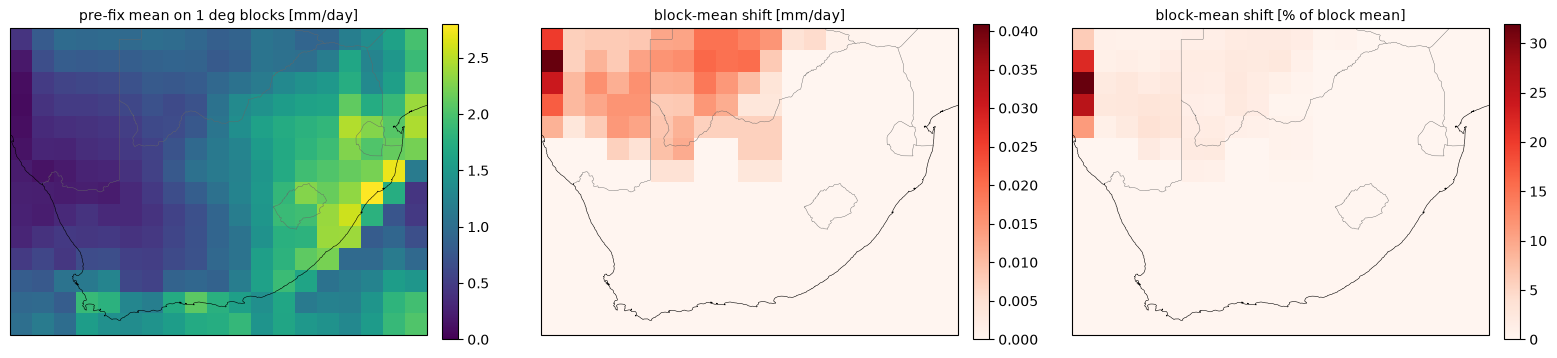

In [11]:
kw = {"lat": COARSEN_FACTOR, "lon": COARSEN_FACTOR, "boundary": "trim"}
coarse = xr.Dataset(
    {
        "pre_mean": mm.pre_mean.coarsen(**kw).mean(),
        "diff_mean": mm.diff_mean.coarsen(**kw).mean(),
        "filled_fraction": mm.filled_fraction.coarsen(**kw).mean(),
    }
)
coarse["diff_pct"] = 100 * coarse.diff_mean / coarse.pre_mean

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), subplot_kw={"projection": ccrs.PlateCarree()})
res = COARSEN_FACTOR * 0.25
draw(
    axes[0], coarse.pre_mean, f"pre-fix mean on {res:g} deg blocks [mm/day]", cmap="viridis", vmin=0
)
draw(axes[1], coarse.diff_mean, "block-mean shift [mm/day]", cmap="Reds", vmin=0)
draw(axes[2], coarse.diff_pct, "block-mean shift [% of block mean]", cmap="Reds", vmin=0)
fig.tight_layout()

## 7. Against the raw GDEX source

Sections 1-6 compare two versions of the *processed* store. The patch is the only step that touched
values after ingestion, so pre-fix should equal the raw GDEX files exactly, up to the coordinate
handling in `preprocess_gdex` (longitude rolled to -180/180, latitude sorted ascending). Checking
that closes the loop: it shows the pre-fix snapshot really is the untouched observation, and that no
other ingestion step is a candidate for the artifact.

The comparison runs on one year, from a local NetCDF3 file (`RAW_NC`). If that file is missing it
falls back to `_open_year`, which pulls the same year over the GDEX HTTP endpoint (about 1.5 GB,
and slow). Set `RAW_NC = None` and `RAW_YEAR = None` to skip the section.

Three quantities to read off:

- `max |raw - pre|` should be **zero**. Anything else means ingestion, not the patch, altered values.
- `max |raw - post|` is the patch's footprint measured against the source of truth, and should match
  the `max |diff|` in section 2 restricted to this year.
- The panels show whether the raw field already carries block structure of its own, which would move
  the artifact upstream of everything in this repo.

In [12]:
import pathlib  # noqa: E402

from saidownscale.input_data.gdex_gmf import _open_year, preprocess_gdex  # noqa: E402

RAW_NC = pathlib.Path("~/Downloads/prcp_0p25_daily_2008-2008.nc").expanduser()
RAW_YEAR = 2008


def open_raw_year(year: int) -> xr.DataArray:
    """One year of raw GDEX daily prcp, from the local file if present, else over HTTP.

    Applies only ``preprocess_gdex``, so what comes back is the raw values on the store's
    coordinate convention. Units are already kg m-2 s-1; the ETL never rescales pr.
    """
    if RAW_NC is not None and RAW_NC.exists():
        ds = xr.open_dataset(RAW_NC, chunks="auto")[["prcp"]]
    else:
        ds = _open_year(year, "prcp")[["prcp"]]
    da = ds.pipe(preprocess_gdex).rename({"prcp": VARIABLE})[VARIABLE]
    return da.sel(time=str(year), lat=LAT_SLICE, lon=LON_SLICE)


if RAW_YEAR is not None:
    raw = open_raw_year(RAW_YEAR)

    # A local file handle (or the HTTP reader) cannot be shipped to cluster workers, so this one
    # reduction runs on the kernel while the store reads stay distributed.
    raw_mean = raw.mean("time").compute(scheduler="threads")

    year_slice = slice(f"{RAW_YEAR}-01-01", f"{RAW_YEAR}-12-31")
    stored = xr.Dataset(
        {
            "pre": pre.sel(time=year_slice).mean("time"),
            "post": post.sel(time=year_slice).mean("time"),
        }
    ).compute()

    # Guard against a float32/float64 coordinate mismatch silently aligning everything to NaN.
    raw_mean = raw_mean.reindex_like(stored.pre, method="nearest", tolerance=1e-4)

    triple = xr.Dataset({"raw": raw_mean, "pre": stored.pre, "post": stored.post}) * SECONDS_PER_DAY

    print(f"raw days: {raw.sizes['time']}, store days: {pre.sel(time=year_slice).sizes['time']}")
    print(f"max |raw - pre|:  {float(abs(triple.raw - triple.pre).max()):.3e} mm/day")
    print(f"max |raw - post|: {float(abs(triple.raw - triple.post).max()):.3e} mm/day")

raw days: 366, store days: 366
max |raw - pre|:  7.153e-07 mm/day
max |raw - post|: 4.981e-02 mm/day


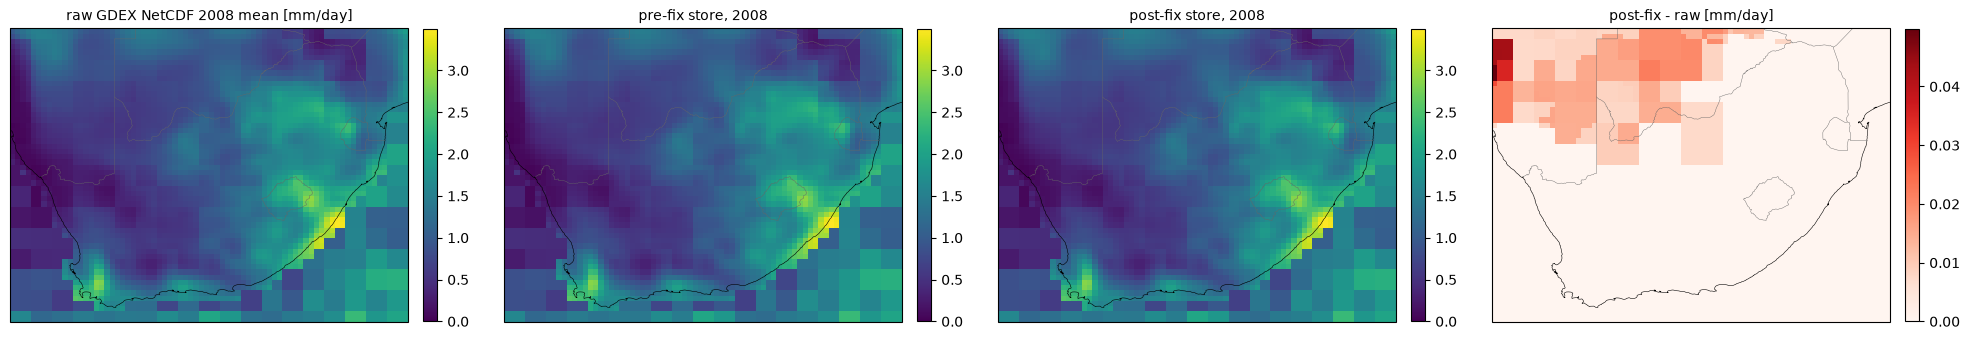

In [13]:
if RAW_YEAR is not None:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.2), subplot_kw={"projection": ccrs.PlateCarree()})
    vmax_raw = float(triple[["raw", "pre", "post"]].to_array().max())
    draw(
        axes[0],
        triple.raw,
        f"raw GDEX NetCDF {RAW_YEAR} mean [mm/day]",
        cmap="viridis",
        vmin=0,
        vmax=vmax_raw,
    )
    draw(axes[1], triple.pre, f"pre-fix store, {RAW_YEAR}", cmap="viridis", vmin=0, vmax=vmax_raw)
    draw(axes[2], triple.post, f"post-fix store, {RAW_YEAR}", cmap="viridis", vmin=0, vmax=vmax_raw)
    draw(axes[3], triple.post - triple.raw, "post-fix - raw [mm/day]", cmap="Reds", vmin=0)
    fig.tight_layout()

### 7.1 Did ingestion change anything?

`post - raw` above is dominated by the patch, so it cannot show whether the ETL itself altered
values. This panel isolates `pre - raw`: the pre-fix store against the source NetCDF, same year.
`preprocess_gdex` only rolls longitude to -180/180 and sorts latitude, and `write_dataset_to_icechunk`
only re-chunks, so the difference should be float32 round-trip noise (order 1e-7 mm/day) with no
spatial structure.

Structure would be the giveaway: a stripe at longitude 0/180 means the `lon_to_180` roll is off by a
cell, a north-south gradient means the latitude sort is, and a coherent regional patch means
something rescaled the values.

In [ ]:
if RAW_YEAR is not None:
    ingest_diff = triple.pre - triple.raw
    eps = float(abs(ingest_diff).max())

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), subplot_kw={"projection": ccrs.PlateCarree()})
    # Symmetric scale at the observed maximum, so pure float noise fills the color range and any
    # real structure stands out against it rather than being flattened by an outlier.
    draw(
        axes[0],
        ingest_diff,
        f"pre-fix store - raw NetCDF [mm/day], max |d| {eps:.2e}",
        cmap="RdBu_r",
        vmin=-eps,
        vmax=eps,
    )
    # Relative to the local mean, which is the scale that matters for a rescaling error.
    draw(
        axes[1],
        100 * ingest_diff / triple.raw,
        "pre-fix - raw [% of raw mean]",
        cmap="RdBu_r",
        vmin=-1e-3,
        vmax=1e-3,
    )
    # float32 has ~7 significant digits, so a round-trip of a value near 1 mm/day lands here.
    axes[2].remove()
    ax = fig.add_subplot(1, 3, 3)
    vals = ingest_diff.values.ravel()
    ax.hist(vals[np.isfinite(vals)], bins=60, color="0.3")
    ax.set_xlabel("pre-fix - raw [mm/day]")
    ax.set_ylabel("cells")
    ax.set_yscale("log")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    float32_eps = np.spacing(np.float32(float(triple.raw.max())))
    print(f"max |pre - raw|:        {eps:.3e} mm/day")
    print(f"float32 ulp at max pr:  {float(float32_eps):.3e} mm/day")
    print(f"identical cells:        {int((ingest_diff == 0).sum())} of {ingest_diff.size}")
    print(f"cells beyond 1e-5 mm/day: {int((abs(ingest_diff) > 1e-5).sum())}")

## 8. Reading the result

Fill in once the cells have run:

- **Amplitude.** Section 2's summary gives the largest all-time-mean shift, absolutely and as a
  percentage. Compare it against the artifact amplitude in the obs-comparison figure (a few times
  1e-6 kg m-2 s-1, against means of about 3e-5). A shift an order of magnitude smaller than the
  artifact rules the patch out as the direct cause.
- **Pattern.** Section 4 shows where the fill landed and section 6 shows what survives coarsening.
  The patch cannot be the cause if the artifact is loud where the fill map is empty.
- **Mechanism.** Even a small shift can matter indirectly: the patch exists precisely because the
  parametric tail fit fails on all-zero windows, and changing which cells fail changes which cells
  fall back. That would show up as blocks whose *edges* follow the fill map even where the
  amplitude does not.

If the patch is exonerated here, the next candidates are the debias step's coarse-cell handling and
the coarse-to-fine interpolation, neither of which this notebook touches.